In [1]:
import pandas as pd
import matplotlib.pyplot as plt

aviation = pd.read_csv(
    "../data/processed/aviation_clean.csv",
    parse_dates=["date"]
)

aviation.head()

,date,month_year,airport_group,airport,total_passengers,terminal_passengers,transit_passengers
0,2015-01-01,January 2015,Other UK Airports,ABERDEEN,249165,249165,0
1,2015-01-01,January 2015,Non UK Reporting Airports,ALDERNEY,2906,2906,0
2,2015-01-01,January 2015,Other UK Airports,BARRA,437,437,0
3,2015-01-01,January 2015,Other UK Airports,BELFAST CITY (GEORGE BEST),167662,167662,0
4,2015-01-01,January 2015,Other UK Airports,BELFAST INTERNATIONAL,237948,237819,129


In [2]:
uk_aviation = aviation[
    aviation["airport_group"] != "Non UK Reporting Airports"
].copy()

uk_aviation.shape

(6230, 7)

In [3]:
monthly_traffic = (
    uk_aviation.groupby("date")["total_passengers"]
    .sum()
    .reset_index()
)

monthly_traffic.head()

,date,total_passengers
0,2015-01-01,15664021
1,2015-02-01,15617632
2,2015-03-01,18539452
3,2015-04-01,20148926
4,2015-05-01,22462867


In [4]:
monthly_traffic.shape

(132, 2)

In [5]:
post_covid = monthly_traffic[
    monthly_traffic["date"] >= "2022-01-01"
].copy()

post_covid.shape

(48, 2)

In [6]:
train = post_covid[
    post_covid["date"] < "2025-01-01"
].copy()

test = post_covid[
    post_covid["date"] >= "2025-01-01"
].copy()

train.shape, test.shape

((36, 2), (12, 2))

In [7]:
test["naive_forecast"] = train["total_passengers"].tail(12).values

test[["date", "total_passengers", "naive_forecast"]]

,date,total_passengers,naive_forecast
120,2025-01-01,18753368,17799649
121,2025-02-01,19089890,18712909
122,2025-03-01,21622615,21656351
123,2025-04-01,24896419,23531787
124,2025-05-01,27176258,26589771
125,2025-06-01,28260669,28021123
126,2025-07-01,30227470,29689451
127,2025-08-01,31143773,30466779
128,2025-09-01,28034894,27722871
129,2025-10-01,26910075,26231217


In [9]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    test["total_passengers"],
    test["naive_forecast"]
)

round(mae)

576144

In [10]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    test["total_passengers"],
    test["naive_forecast"]
)

mape * 100

2.3827399638069267

In [11]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(
    test["total_passengers"],
    test["naive_forecast"]
)

round(rmse)

664720

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [13]:
model = ExponentialSmoothing(
    train["total_passengers"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

In [14]:
fitted_model = model.fit()

In [15]:
hw_forecast = fitted_model.forecast(12)

hw_forecast

120    1.867122e+07
121    1.974629e+07
122    2.309559e+07
123    2.594995e+07
124    2.844865e+07
125    2.993617e+07
126    3.175116e+07
127    3.209103e+07
128    2.979656e+07
129    2.870858e+07
130    2.271460e+07
131    2.379870e+07
dtype: float64

In [16]:
test["hw_forecast"] = hw_forecast.values

test[[
    "date",
    "total_passengers",
    "naive_forecast",
    "hw_forecast"
]]

,date,total_passengers,naive_forecast,hw_forecast
120,2025-01-01,18753368,17799649,1.867122e+07
121,2025-02-01,19089890,18712909,1.974629e+07
122,2025-03-01,21622615,21656351,2.309559e+07
123,2025-04-01,24896419,23531787,2.594995e+07
124,2025-05-01,27176258,26589771,2.844865e+07
125,2025-06-01,28260669,28021123,2.993617e+07
126,2025-07-01,30227470,29689451,3.175116e+07
127,2025-08-01,31143773,30466779,3.209103e+07
128,2025-09-01,28034894,27722871,2.979656e+07
129,2025-10-01,26910075,26231217,2.870858e+07


In [17]:
hw_mae = mean_absolute_error(
    test["total_passengers"],
    test["hw_forecast"]
)

round(hw_mae)

1288058

In [18]:
hw_mape = mean_absolute_percentage_error(
    test["total_passengers"],
    test["hw_forecast"]
)

hw_mape * 100

5.1306030585251685

In [19]:
hw_rmse = root_mean_squared_error(
    test["total_passengers"],
    test["hw_forecast"]
)

round(hw_rmse)

1386861

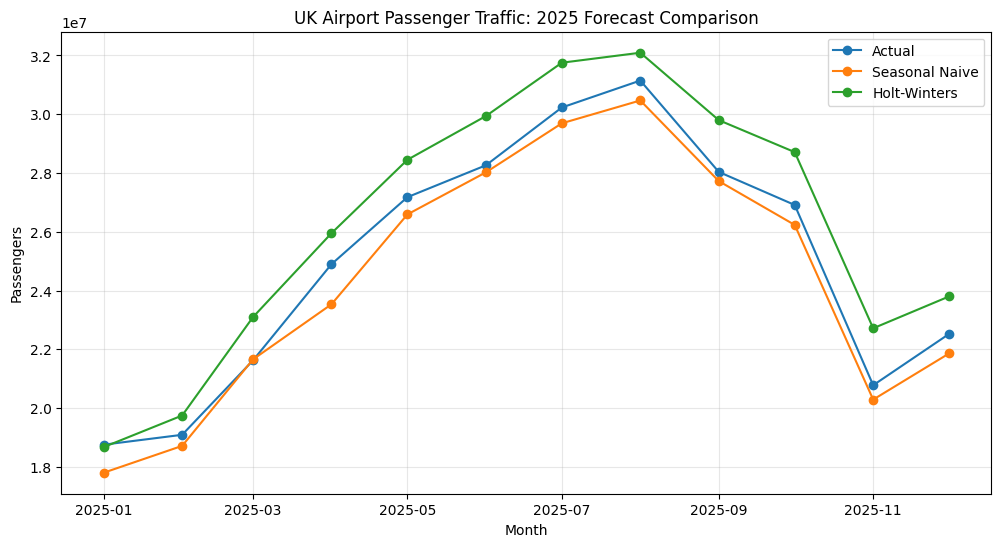

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    test["total_passengers"],
    marker="o",
    label="Actual"
)

plt.plot(
    test["date"],
    test["naive_forecast"],
    marker="o",
    label="Seasonal Naive"
)

plt.plot(
    test["date"],
    test["hw_forecast"],
    marker="o",
    label="Holt-Winters"
)

plt.title("UK Airport Passenger Traffic: 2025 Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

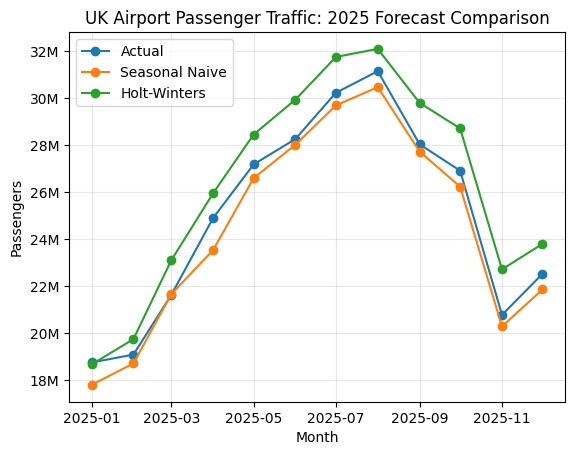

In [26]:

plt.plot(
    test["date"],
    test["total_passengers"],
    marker="o",
    label="Actual"
)

plt.plot(
    test["date"],
    test["naive_forecast"],
    marker="o",
    label="Seasonal Naive"
)

plt.plot(
    test["date"],
    test["hw_forecast"],
    marker="o",
    label="Holt-Winters"
)

plt.title("UK Airport Passenger Traffic: 2025 Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)

from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.0f}M")
)

plt.show()

In [27]:
model_comparison = pd.DataFrame({
    "Model": ["Seasonal Naive", "Holt-Winters"],
    "MAE": [mae, hw_mae],
    "MAPE (%)": [mape * 100, hw_mape * 100],
    "RMSE": [rmse, hw_rmse]
})

model_comparison

,Model,MAE,MAPE (%),RMSE
0,Seasonal Naive,5.761441e+05,2.382740,6.647202e+05
1,Holt-Winters,1.288058e+06,5.130603,1.386861e+06


In [28]:
model_comparison.style.format({
    "MAE": "{:,.0f}",
    "MAPE (%)": "{:.2f}%",
    "RMSE": "{:,.0f}"
})

,Model,MAE,MAPE (%),RMSE
0,Seasonal Naive,"576,144",2.38%,"664,720"
1,Holt-Winters,"1,288,058",5.13%,"1,386,861"


In [29]:
forecast_2026 = test[[
    "date",
    "total_passengers"
]].copy()

forecast_2026["date"] = (
    forecast_2026["date"] + pd.DateOffset(years=1)
)

forecast_2026 = forecast_2026.rename(
    columns={"total_passengers": "forecast_passengers"}
)

forecast_2026

,date,forecast_passengers
120,2026-01-01,18753368
121,2026-02-01,19089890
122,2026-03-01,21622615
123,2026-04-01,24896419
124,2026-05-01,27176258
125,2026-06-01,28260669
126,2026-07-01,30227470
127,2026-08-01,31143773
128,2026-09-01,28034894
129,2026-10-01,26910075


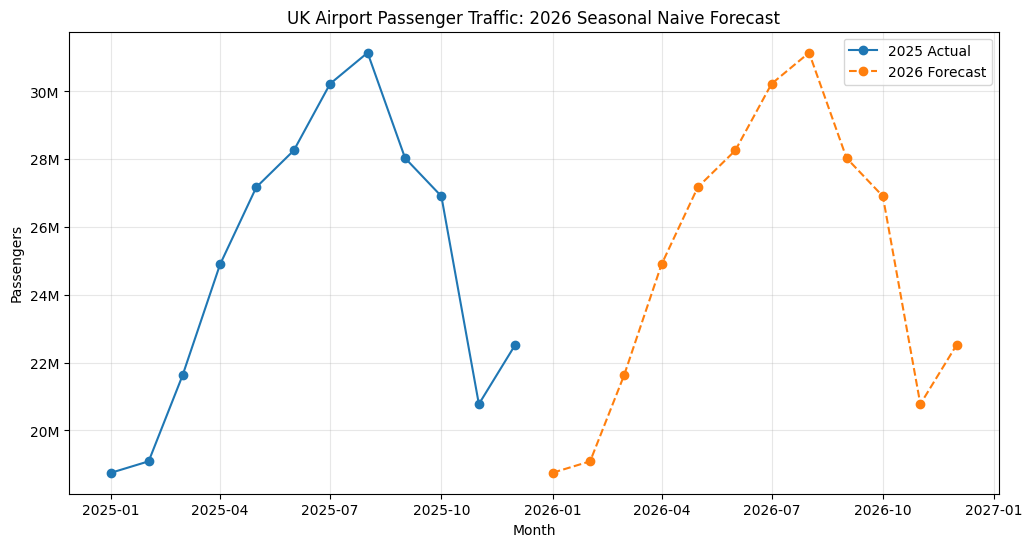

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    test["total_passengers"],
    marker="o",
    label="2025 Actual"
)

plt.plot(
    forecast_2026["date"],
    forecast_2026["forecast_passengers"],
    marker="o",
    linestyle="--",
    label="2026 Forecast"
)

plt.title("UK Airport Passenger Traffic: 2026 Seasonal Naive Forecast")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1_000_000:.0f}M")
)

plt.show()

## Forecasting Conclusions

- A Seasonal Naive model and a Holt-Winters Exponential Smoothing model were evaluated using 2025 as the test period.
- The Seasonal Naive model performed substantially better, achieving a **MAPE of 2.38%**, compared with **5.13% for Holt-Winters**.
- Seasonal Naive also produced lower MAE (**576,144**) and RMSE (**664,720**), outperforming Holt-Winters across all three evaluation metrics.
- This indicates that the previous year's corresponding month provides a strong short-term benchmark for UK airport passenger traffic.
- Based on this performance, Seasonal Naive was selected to produce an illustrative forecast for 2026.
- The 2026 forecast preserves the strong seasonal pattern observed in 2025, with passenger traffic rising through spring and summer, peaking in August, and falling during autumn and winter.

### Limitations

- The Seasonal Naive forecast assumes that each month of 2026 will have the same passenger traffic as the corresponding month of 2025.
- It therefore captures seasonality but does not model underlying growth or decline.
- The forecast does not account for unexpected events such as economic shocks, airline capacity changes, geopolitical events, or other disruptions.
- The 2026 figures should therefore be interpreted as a **baseline forecast rather than a precise prediction**.